# SMS Spam Detection using Linear Regression

**Repositori**: Machine Learning  
**Topik**: Implementasi Linear Regression pada Klasifikasi SMS Spam  
**Dataset**: `SMSSpam.csv`  

---

## Pendahuluan
Proyek ini mendemonstrasikan implementasi **Linear Regression** untuk tugas klasifikasi teks (Spam vs Ham). Meskipun secara teoretis Logistic Regression lebih tepat untuk klasifikasi, notebook ini mengikuti panduan modul praktikum untuk mengeksplorasi penggunaan model regresi linear dalam memprediksi label biner.

### Alur Kerja (Pipeline):
1. **Data Acquisition**: Mengambil data dari CSV.
2. **EDA (Exploratory Data Analysis)**: Menganalisis distribusi dan karakteristik data.
3. **Data Preparation**: Cleaning dan Label Encoding (Ham=0, Spam=1).
4. **Feature Engineering**: Transformasi teks menggunakan TF-IDF.
5. **Modeling**: Training menggunakan Linear Regression.
6. **Evaluation**: Menggunakan Confusion Matrix, Accuracy, Precision, dan Recall.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Setting estetika visual
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 🛠 1. Data Acquisition & Understanding
Memuat dataset dan melihat struktur data awal.

In [2]:
# Memuat data tanpa header karena SMSSpam.csv biasanya tidak memiliki header di baris pertama
df = pd.read_csv('../../data/SMSSpam.csv', names=['Label', 'Message'], encoding='latin-1')

print("Shape Dataset:", df.shape)
df.head()

Shape Dataset: (5574, 2)


,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 📊 2. Exploratory Data Analysis (EDA)
Menganalisis karakteristik dataset sebelum preprocessing.

Missing Values:
 Label      0
Message    0
dtype: int64

Distribusi Label:
Label
ham     4827
spam     747
Name: count, dtype: int64

Persentase:
Label
ham     86.6
spam    13.4
Name: proportion, dtype: float64

Statistik Panjang Pesan:
count    5574.000000
mean       80.585396
std        59.910725
min         2.000000
25%        36.000000
50%        62.000000
75%       122.000000
max       910.000000
Name: Message_Length, dtype: float64


C:\Users\alema\AppData\Local\Temp\ipykernel_1156\623784132.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='Message_Length', palette='viridis', ax=axes[1])


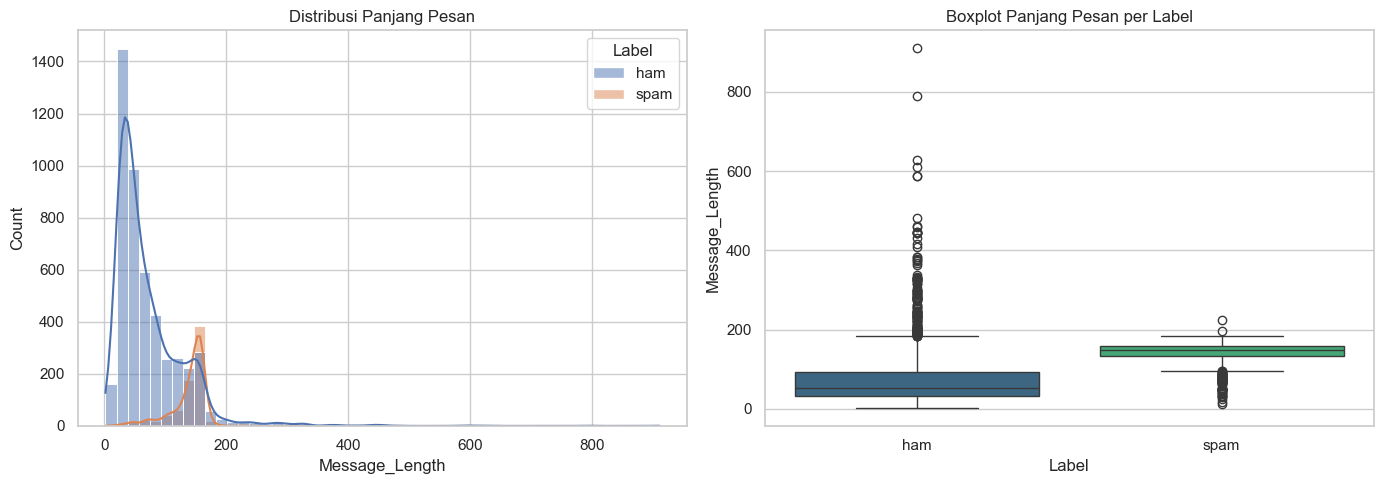

In [3]:
# Cek missing values
print("Missing Values:\n", df.isnull().sum())

# Statistik deskriptif label
print("\nDistribusi Label:")
print(df['Label'].value_counts())
print(f"\nPersentase:\n{df['Label'].value_counts(normalize=True).mul(100).round(2)}")

# Analisis panjang pesan
df['Message_Length'] = df['Message'].apply(len)
print(f"\nStatistik Panjang Pesan:")
print(df['Message_Length'].describe())

# Visualisasi distribusi panjang pesan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='Message_Length', hue='Label', bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribusi Panjang Pesan')
sns.boxplot(data=df, x='Label', y='Message_Length', palette='viridis', ax=axes[1])
axes[1].set_title('Boxplot Panjang Pesan per Label')
plt.tight_layout()
plt.show()

## 🧹 3. Data Preparation & Cleaning
Melakukan encoding pada label dan membersihkan data jika diperlukan.

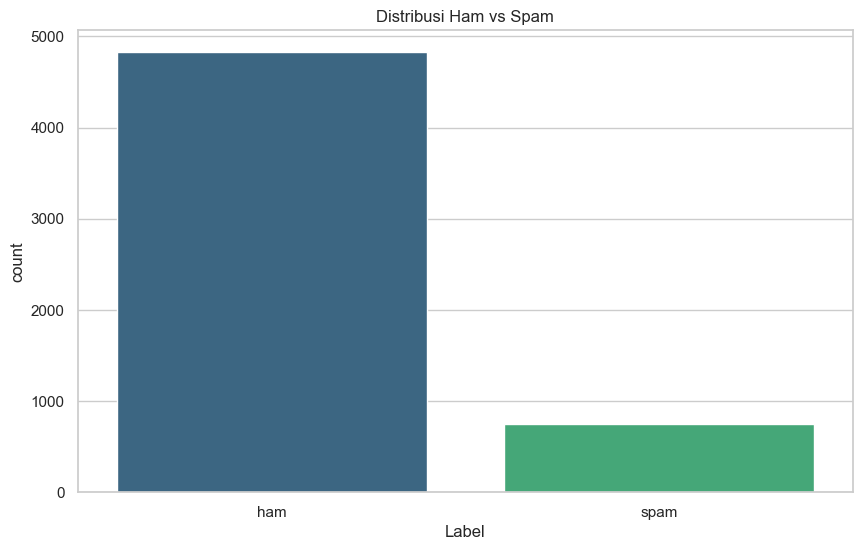

In [4]:
# Mengubah Label menjadi angka (Categorical Encoding)
# ham = 0, spam = 1
df['Label_Num'] = df['Label'].map({'ham': 0, 'spam': 1})

# Cek distribusi data
sns.countplot(x='Label', data=df, hue='Label', palette='viridis', legend=False)
plt.title('Distribusi Ham vs Spam')
plt.show()

## 🧪 4. Feature Engineering (TF-IDF)
Mengubah teks pesan menjadi representasi angka menggunakan TF-IDF Vectorizer.

In [5]:
tfidf = TfidfVectorizer(stop_words='english', max_features=3000)
X = tfidf.fit_transform(df['Message'])
y = df['Label_Num']

# Split data: Training 60%, Validation 20%, Testing 20%
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Data Training: {X_train.shape[0]} sampel")
print(f"Data Validation: {X_val.shape[0]} sampel")
print(f"Data Testing: {X_test.shape[0]} sampel")

Data Training: 3344 sampel
Data Validation: 1115 sampel
Data Testing: 1115 sampel


## 🤖 5. Model Training (Linear Regression)
Melatih model dan mencari threshold optimal via ROC Curve pada validation set.

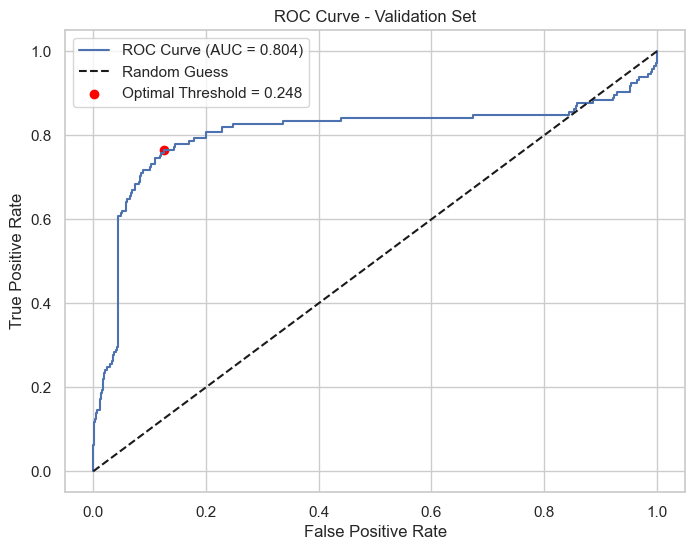

Threshold Optimal: 0.248
TPR (Recall): 0.766
FPR: 0.125


In [6]:
from sklearn.metrics import roc_curve, auc

model = LinearRegression()
model.fit(X_train, y_train)

# Prediksi pada validation set untuk mencari threshold optimal
y_val_continuous = model.predict(X_val)

# Cari threshold optimal berdasarkan Youden's Index (J = TPR - FPR)
fpr, tpr, thresholds = roc_curve(y_val, y_val_continuous)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc(fpr, tpr):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red',
            label=f'Optimal Threshold = {optimal_threshold:.3f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Validation Set')
plt.legend()
plt.show()

print(f"Threshold Optimal: {optimal_threshold:.3f}")
print(f"TPR (Recall): {tpr[optimal_idx]:.3f}")
print(f"FPR: {fpr[optimal_idx]:.3f}")

# Prediksi pada test set dengan threshold optimal
y_test_continuous = model.predict(X_test)
y_pred = [1 if x >= optimal_threshold else 0 for x in y_test_continuous]

## 📊 6. Performance Evaluation
Mengevaluasi model menggunakan metrik yang telah didefinisikan di `README.md`.

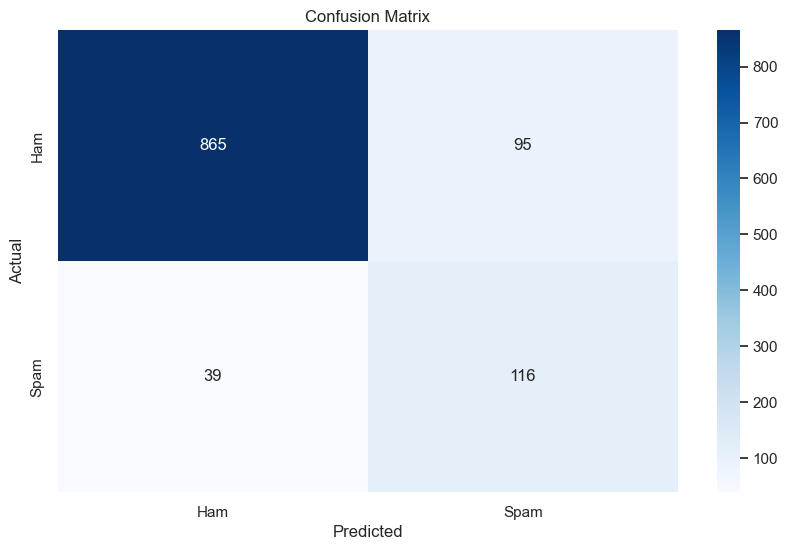

--- Laporan Klasifikasi ---
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       960
           1       0.55      0.75      0.63       155

    accuracy                           0.88      1115
   macro avg       0.75      0.82      0.78      1115
weighted avg       0.90      0.88      0.89      1115

Accuracy: 0.88


In [7]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Metrik Evaluasi
print("--- Laporan Klasifikasi ---")
print(classification_report(y_test, y_pred))

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2f}")

## 📝 Kesimpulan
Model Linear Regression dengan optimasi threshold via ROC Curve pada validation set mampu memberikan hasil yang cukup baik untuk klasifikasi SMS Spam. Pendekatan ini mengatasi kelemahan threshold tetap 0.5 pada data tidak seimbang (imbalanced). Namun, untuk dataset ini, model berbasis probabilitas seperti Naive Bayes atau Logistic Regression biasanya lebih direkomendasikan.